# Predictive Maintenance & Equipment Failure Analytics

## Exploratory Data Analysis

This notebook performs exploratory data analysis on the AI4I 2020 Predictive Maintenance Dataset to understand machine operating conditions and identify patterns associated with equipment failure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 1. Load Dataset

In [8]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.shape

(10000, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [11]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

## 2. Data Quality Check

In [12]:
missing_values = df.isnull().sum()

missing_values

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["Product ID"].duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [17]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [18]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## 3. Univariate Analysis

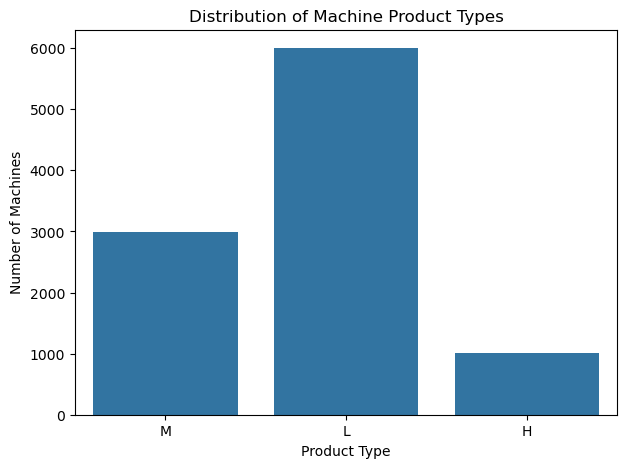

In [22]:
# Product Type Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Type")

plt.title("Distribution of Machine Product Types")
plt.xlabel("Product Type")
plt.ylabel("Number of Machines")

plt.show()

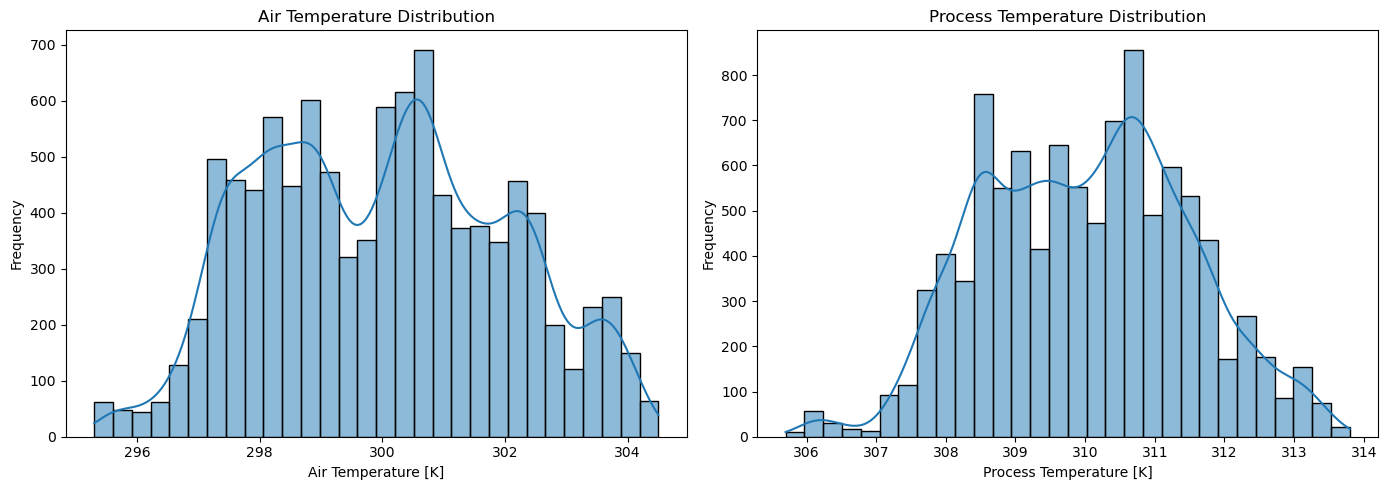

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Air temperature [K]", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Air Temperature Distribution")
axes[0].set_xlabel("Air Temperature [K]")
axes[0].set_ylabel("Frequency")

sns.histplot(data=df, x="Process temperature [K]", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Process Temperature Distribution")
axes[1].set_xlabel("Process Temperature [K]")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

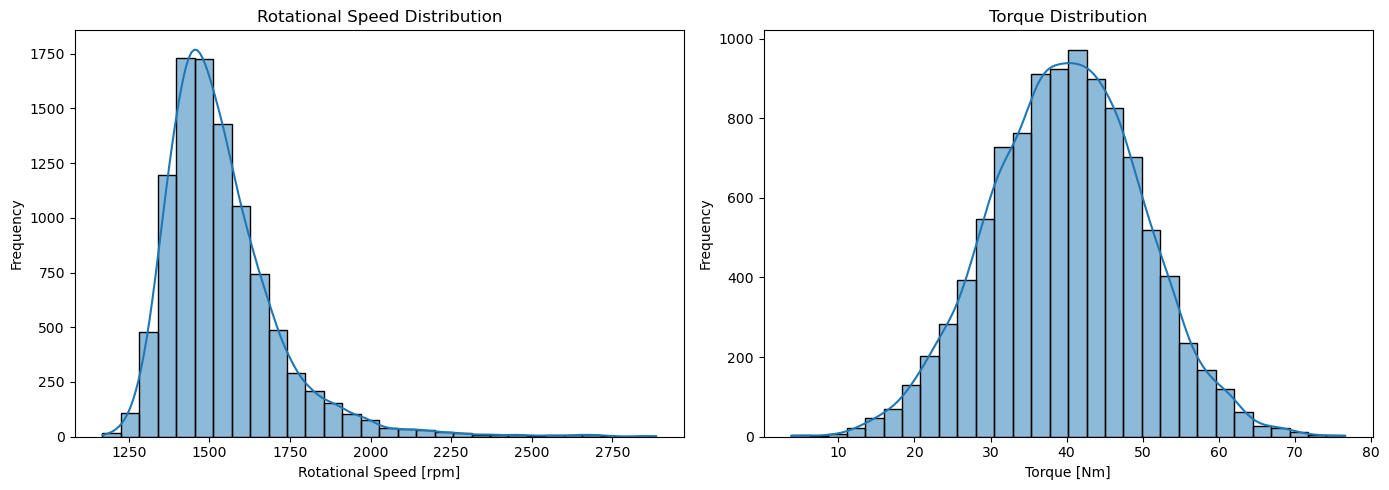

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Rotational speed [rpm]", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Rotational Speed Distribution")
axes[0].set_xlabel("Rotational Speed [rpm]")
axes[0].set_ylabel("Frequency")

sns.histplot(data=df, x="Torque [Nm]", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Torque Distribution")
axes[1].set_xlabel("Torque [Nm]")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

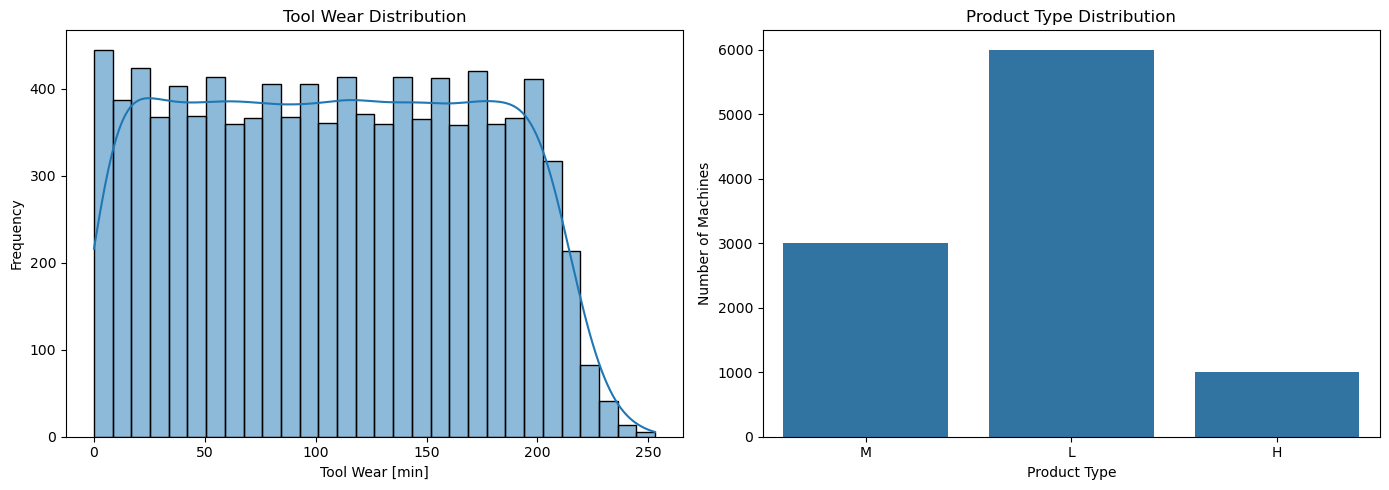

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="Tool wear [min]", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Tool Wear Distribution")
axes[0].set_xlabel("Tool Wear [min]")
axes[0].set_ylabel("Frequency")

sns.countplot(data=df, x="Type", ax=axes[1])
axes[1].set_title("Product Type Distribution")
axes[1].set_xlabel("Product Type")
axes[1].set_ylabel("Number of Machines")

plt.tight_layout()
plt.show()

## 4. Machine Failure Analysis

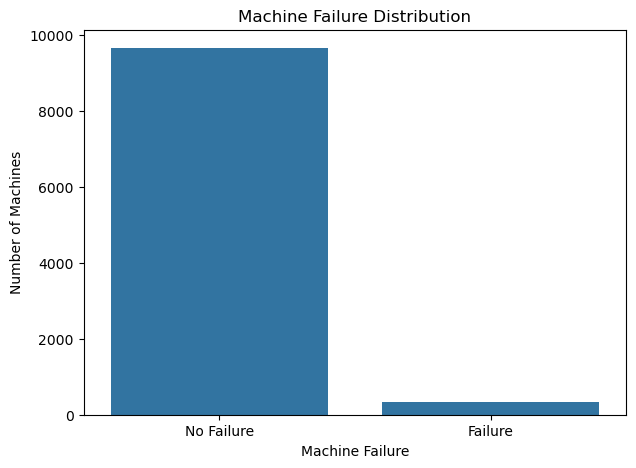

In [26]:
failure_counts = df["Machine failure"].value_counts()

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")

plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

In [27]:
failure_rate = df["Machine failure"].value_counts(normalize=True) * 100

failure_rate

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## 5. Failure Rate by Product Type

In [28]:
failure_by_type = (
    df.groupby("Type")["Machine failure"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

failure_by_type["failure_rate_%"] = failure_by_type["mean"] * 100

failure_by_type

,Type,count,sum,mean,failure_rate_%
0,H,1003,21,0.020937,2.093719
1,L,6000,235,0.039167,3.916667
2,M,2997,83,0.027694,2.769436


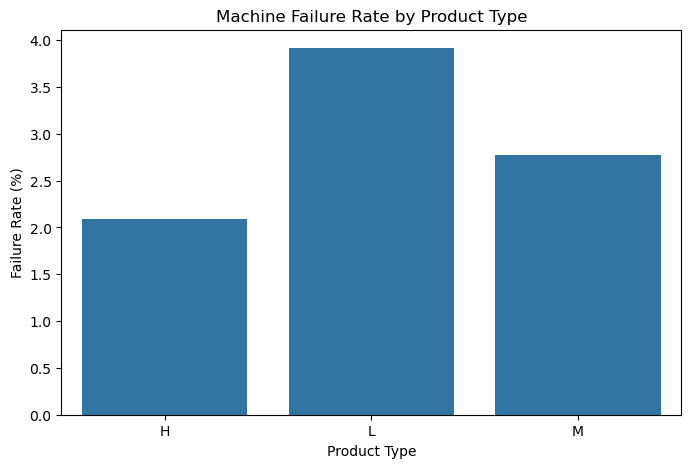

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=failure_by_type,
    x="Type",
    y="failure_rate_%"
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")

plt.show()

## 6. Failure Rate by Tool Wear

In [30]:
df["Tool Wear Group"] = pd.cut(
    df["Tool wear [min]"],
    bins=[-1, 50, 100, 150, 200, 253],
    labels=["0-50", "51-100", "101-150", "151-200", "201-253"]
)

tool_wear_failure = (
    df.groupby("Tool Wear Group", observed=False)["Machine failure"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

tool_wear_failure["failure_rate_%"] = tool_wear_failure["mean"] * 100

tool_wear_failure

,Tool Wear Group,count,sum,mean,failure_rate_%
0,0-50,2396,52,0.021703,2.170284
1,51-100,2271,53,0.023338,2.333774
2,101-150,2295,50,0.021786,2.178649
3,151-200,2276,66,0.028998,2.899824
4,201-253,762,118,0.154856,15.485564


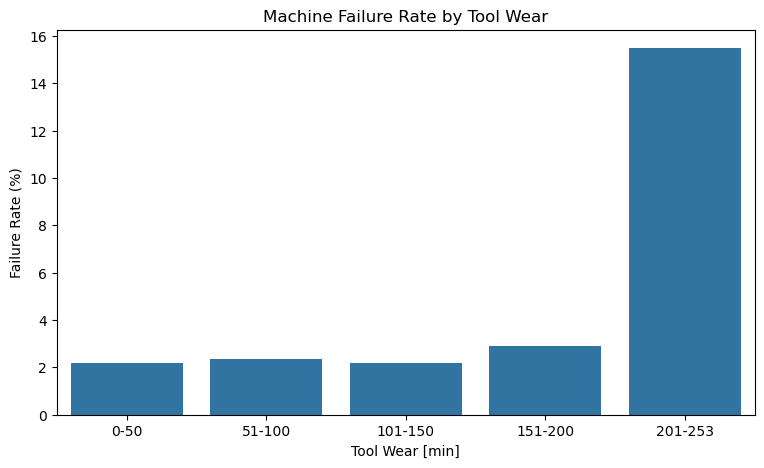

In [31]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tool_wear_failure,
    x="Tool Wear Group",
    y="failure_rate_%"
)

plt.title("Machine Failure Rate by Tool Wear")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Failure Rate (%)")

plt.show()

## 7. Machine Failure vs Operating Conditions

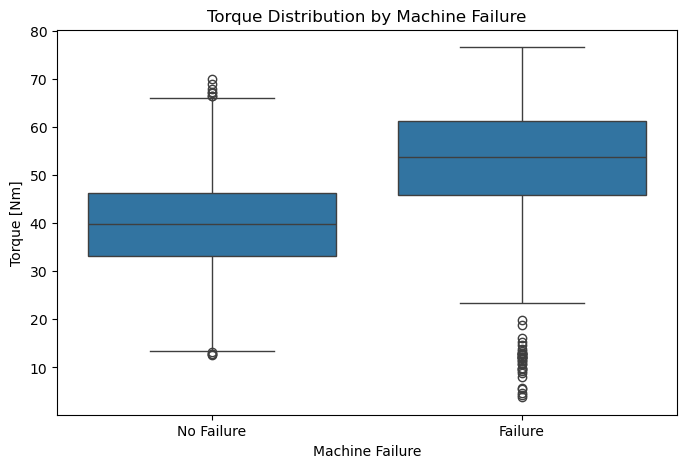

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Torque [Nm]"
)

plt.title("Torque Distribution by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Torque [Nm]")
plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

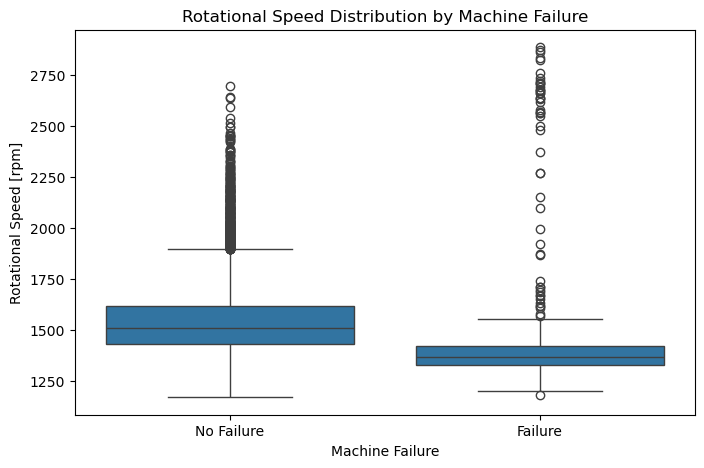

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Rotational speed [rpm]"
)

plt.title("Rotational Speed Distribution by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Rotational Speed [rpm]")
plt.xticks([0, 1], ["No Failure", "Failure"])

plt.show()

## 8. Temperature vs Machine Failure

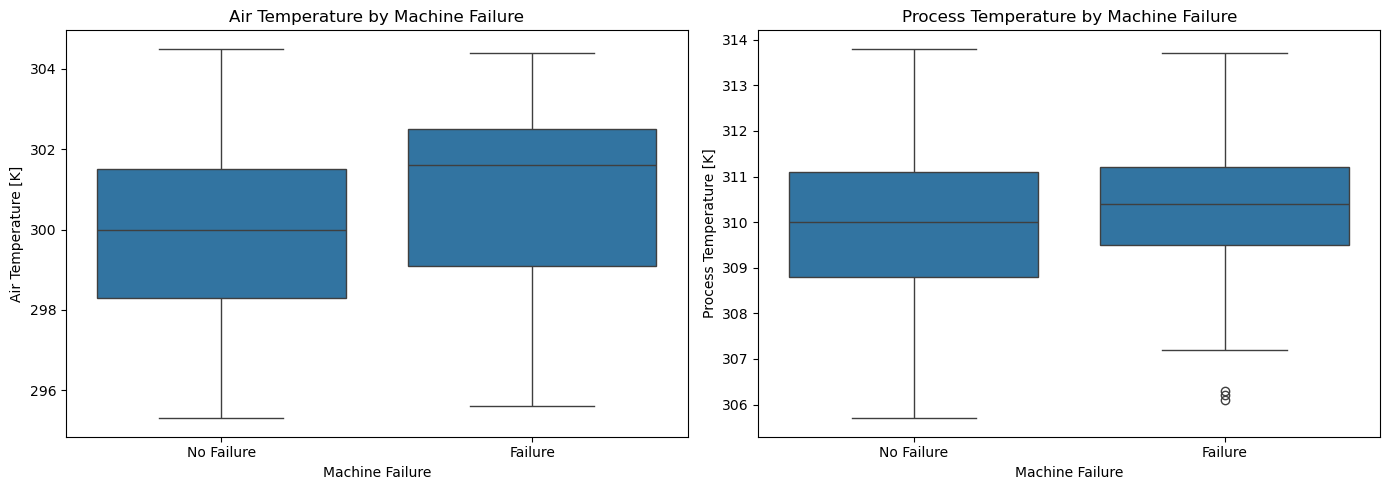

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Machine failure",
    y="Air temperature [K]",
    ax=axes[0]
)

axes[0].set_title("Air Temperature by Machine Failure")
axes[0].set_xlabel("Machine Failure")
axes[0].set_ylabel("Air Temperature [K]")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Failure", "Failure"])


sns.boxplot(
    data=df,
    x="Machine failure",
    y="Process temperature [K]",
    ax=axes[1]
)

axes[1].set_title("Process Temperature by Machine Failure")
axes[1].set_xlabel("Machine Failure")
axes[1].set_ylabel("Process Temperature [K]")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["No Failure", "Failure"])

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

Correlation analysis is used to examine the linear relationships between numerical machine characteristics and equipment failure.

In [35]:
correlation_matrix = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
].corr()

correlation_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


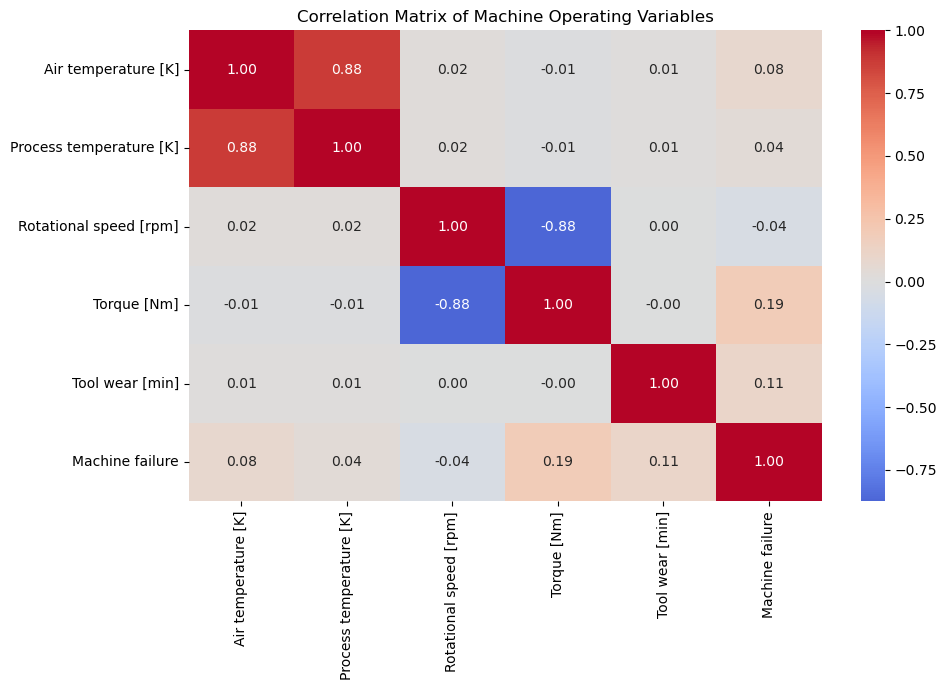

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Machine Operating Variables")

plt.tight_layout()
plt.show()

## 10. Failure Mode Analysis

The dataset contains individual indicators describing different observed machine failure modes. Analyzing these indicators helps identify which failure modes contribute to the overall machine failure target.

In [37]:
failure_modes = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

failure_mode_counts = df[failure_modes].sum().sort_values(ascending=False)

failure_mode_counts

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

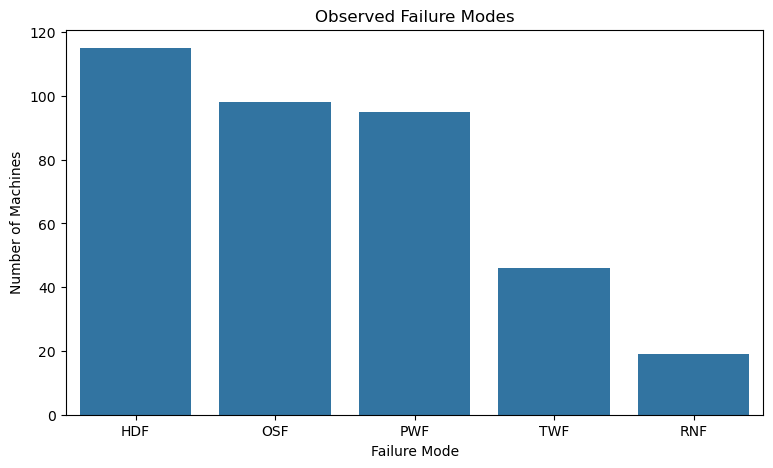

In [38]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=failure_mode_counts.index,
    y=failure_mode_counts.values
)

plt.title("Observed Failure Modes")
plt.xlabel("Failure Mode")
plt.ylabel("Number of Machines")

plt.show()

In [39]:
failure_mode_rates = (
    df[failure_modes].mean() * 100
).sort_values(ascending=False)

failure_mode_rates


HDF    1.15
OSF    0.98
PWF    0.95
TWF    0.46
RNF    0.19
dtype: float64

## 11. Exploratory Data Analysis – Key Findings

The exploratory analysis identified several important patterns in the machine-failure dataset:

- The dataset contains **10,000 machine records** with no missing values.
- Only **3.39% of machines experienced failure**, indicating a highly imbalanced target variable.
- **L-type machines** had the highest observed failure rate at approximately **3.92%**.
- Machines with **201–253 minutes of tool wear** showed a substantially higher observed failure rate of approximately **15.49%**, compared with less than 3% in the other tool-wear groups.
- Failed machines showed a noticeably higher **median torque** than non-failed machines.
- Failed machines showed a lower typical rotational speed, while also containing numerous high-speed observations.
- Air temperature and process temperature were strongly correlated with each other.
- Rotational speed and torque showed a strong negative correlation.
- Torque had the strongest linear correlation with machine failure among the analyzed numerical variables.
- Correlation alone did not fully explain failure patterns, highlighting the importance of considering nonlinear relationships and feature interactions.
- Among the recorded failure modes, **HDF (Heat Dissipation Failure)** was the most frequently observed, followed by OSF and PWF.
- The failure-mode indicators provide additional information about the types of failures observed in the dataset.

These findings will guide the feature engineering and machine-learning stages of the predictive maintenance analysis.

In [41]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Tool Wear Group'],
      dtype='object')

In [42]:
# Create a clean dataset for machine learning
df_model = df.drop(columns=["Tool Wear Group"]).copy()

In [44]:
df_model.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [45]:
df_model.shape

(10000, 14)

## 12. Predictive Maintenance – Machine Learning

The next stage uses machine learning to predict whether a machine is likely to experience failure based on its operating conditions and historical machine characteristics.

In [47]:
X = df_model.drop(columns=["Machine failure"])
y = df_model["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (10000, 13)
y shape: (10000,)

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [48]:
# Remove failure-mode indicators to avoid target leakage
leakage_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

X = df_model.drop(
    columns=["Machine failure"] + leakage_columns
)

y = df_model["Machine failure"]

print("X shape:", X.shape)
print("Features:")
print(X.columns.tolist())

X shape: (10000, 8)
Features:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [49]:
X = X.drop(columns=["UDI", "Product ID"])

print("X shape:", X.shape)
print("Features:")
print(X.columns.tolist())

X shape: (10000, 6)
Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (8000, 6)
Testing set: (2000, 6)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [51]:
print(
    "\nTraining failure rate:",
    f"{y_train.mean() * 100:.2f}%"
)

print(
    "Testing failure rate:",
    f"{y_test.mean() * 100:.2f}%"
)


Training failure rate: 3.39%
Testing failure rate: 3.40%


## 13. Feature Preprocessing

The dataset contains both categorical and numerical features. Categorical variables will be one-hot encoded, while numerical variables will be passed through for tree-based models.

The preprocessing steps are implemented using a `ColumnTransformer` so that transformations are learned only from the training data.

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

## 14. Baseline Model – Logistic Regression

Logistic Regression is used as the baseline classification model. It provides a simple and interpretable benchmark for predicting machine failure.

Because the target variable is highly imbalanced, model performance will be evaluated using precision, recall, F1-score, ROC-AUC, and the confusion matrix rather than accuracy alone.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [55]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

## 15. Logistic Regression – Model Evaluation

The baseline model is evaluated using a confusion matrix, precision, recall, F1-score, and ROC-AUC.

Because machine failure is highly imbalanced, accuracy alone is not sufficient to evaluate model performance.

In [57]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000

ROC-AUC Score:
0.9069008037997809


In [58]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[1598,  334],
       [  12,   56]])

### Baseline Model Findings

The Logistic Regression baseline achieved a ROC-AUC of approximately **0.907** and detected **82% of the observed machine failures**.

However, the model produced a relatively low precision of **14%** for the failure class, resulting in a failure-class F1-score of **0.24**. The confusion matrix shows that 56 of 68 actual failures were correctly identified, while 334 non-failure machines were incorrectly flagged as failures.

This demonstrates the trade-off between detecting failures and generating false alarms in an imbalanced predictive-maintenance problem.

Further models will be evaluated to determine whether nonlinear algorithms can improve the balance between failure detection and false positives.

## 16. Random Forest Model

Random Forest is a tree-based ensemble model that can capture nonlinear relationships and interactions between machine operating variables.

The model uses class weighting to account for the strong imbalance between failure and non-failure observations.

In [59]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [60]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [61]:
rf_pred = random_forest_pipeline.predict(X_test)
rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [62]:
print("Classification Report:")
print(classification_report(y_test, rf_pred))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, rf_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.91      0.46      0.61        68

    accuracy                           0.98      2000
   macro avg       0.95      0.73      0.80      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC Score:
0.9584627329192548


In [63]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[1929,    3],
       [  37,   31]])

### Random Forest Findings

The Random Forest model achieved a ROC-AUC of **0.958**, outperforming the Logistic Regression baseline.

The model achieved **91% precision** for the failure class but only **46% recall**, correctly identifying 31 of the 68 observed failures while producing only 3 false positives.

Compared with Logistic Regression, Random Forest substantially reduced false alarms but missed more actual failures. This highlights an important precision-recall trade-off in predictive maintenance.

The final model should therefore be selected based on the operational objective rather than accuracy or ROC-AUC alone.

## 17. Gradient Boosting Model

Gradient Boosting is an ensemble learning method that builds a sequence of decision trees, where each new tree attempts to improve the errors made by the previous trees.

It is included as a third model to determine whether boosting can provide a better balance between detecting machine failures and limiting false alarms.

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [65]:
gradient_boosting_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
gb_pred = gradient_boosting_pipeline.predict(X_test)
gb_prob = gradient_boosting_pipeline.predict_proba(X_test)[:, 1]

In [67]:
print("Classification Report:")
print(classification_report(y_test, gb_pred))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, gb_prob))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.68      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC Score:
0.9650963646328097


In [68]:
gb_cm = confusion_matrix(y_test, gb_pred)

gb_cm

array([[1928,    4],
       [  22,   46]])

## 18. Model Comparison

In [69]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Failure Precision": [
        0.14,
        0.91,
        0.92
    ],
    "Failure Recall": [
        0.82,
        0.46,
        0.68
    ],
    "Failure F1": [
        0.24,
        0.61,
        0.78
    ],
    "ROC-AUC": [
        0.9069,
        0.9585,
        0.9651
    ]
})

model_comparison

,Model,Failure Precision,Failure Recall,Failure F1,ROC-AUC
0,Logistic Regression,0.14,0.82,0.24,0.9069
1,Random Forest,0.91,0.46,0.61,0.9585
2,Gradient Boosting,0.92,0.68,0.78,0.9651


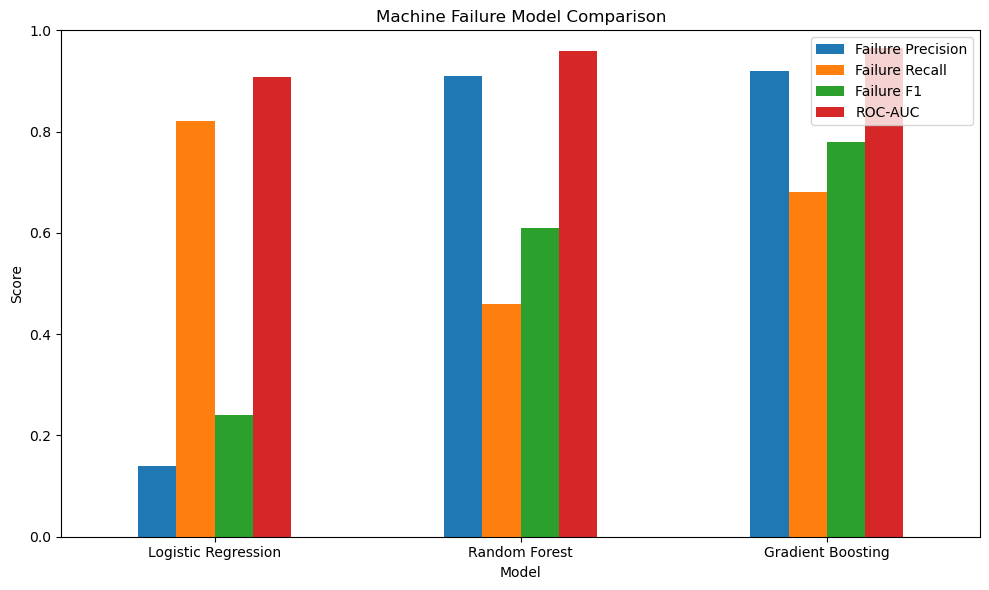

In [72]:
ax = model_comparison.set_index("Model")[
    ["Failure Precision", "Failure Recall", "Failure F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Machine Failure Model Comparison")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Model Comparison Findings

Gradient Boosting achieved the strongest overall performance among the three evaluated models, with a failure-class precision of **92%**, recall of **68%**, F1-score of **78%**, and ROC-AUC of **0.965**.

Logistic Regression achieved the highest failure recall at **82%**, but its failure precision was only **14%**, resulting in a high number of false alarms.

Random Forest achieved high failure precision (**91%**) but detected only **46%** of actual failures.

Gradient Boosting provides the best balance between failure detection and false-alarm reduction among the evaluated models and is therefore selected as the candidate final model.

## 19. Feature Importance

Feature importance is used to identify the machine operating variables that contribute most to the Gradient Boosting model's predictions.

This helps translate the machine learning results into actionable predictive-maintenance insights.

In [73]:
# Get the fitted preprocessing step
fitted_preprocessor = gradient_boosting_pipeline.named_steps["preprocessor"]

# Get the fitted Gradient Boosting model
gb_model = gradient_boosting_pipeline.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Extract feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,numerical__Torque [Nm],0.449769
7,numerical__Tool wear [min],0.177051
5,numerical__Rotational speed [rpm],0.157553
3,numerical__Air temperature [K],0.116040
4,numerical__Process temperature [K],0.076764
1,categorical__Type_L,0.019257
2,categorical__Type_M,0.002228
0,categorical__Type_H,0.001337


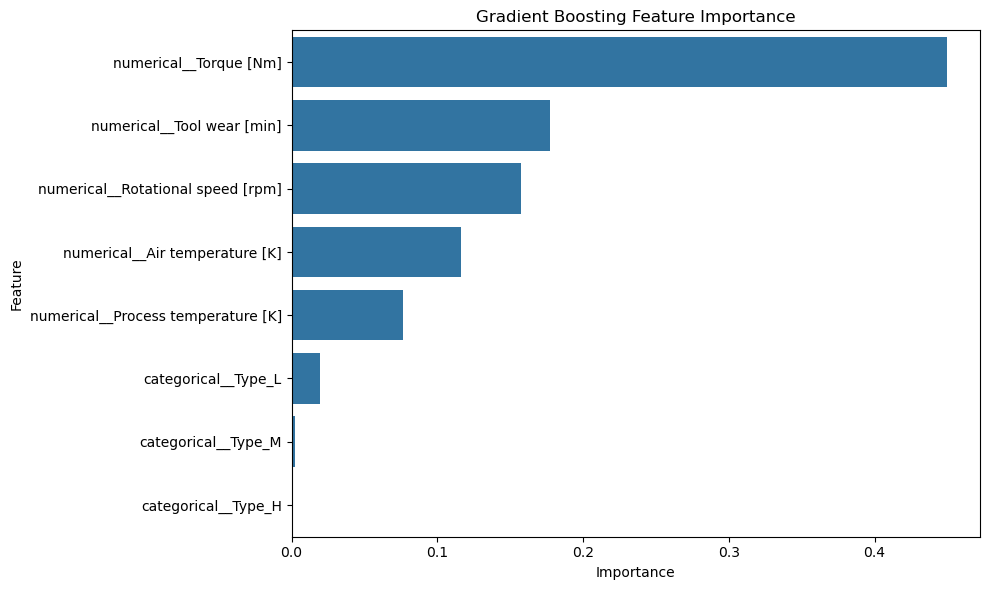

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Feature Importance Findings

The Gradient Boosting model identifies **Torque [Nm]** as the most influential feature, with an importance of approximately **0.45**.

**Tool wear [min]** and **Rotational speed [rpm]** are the next most influential variables, followed by air temperature and process temperature.

The product `Type` variables have relatively low importance, suggesting that machine operating conditions are substantially more influential than product type in the model's predictions.

These findings are consistent with the exploratory analysis, where torque, rotational speed, and tool wear showed meaningful relationships with machine failure.

## 20. Final Model Evaluation

Gradient Boosting was selected as the candidate final model because it provided the strongest balance between failure detection and false-alarm reduction among the evaluated models.

In [75]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

print("Final Model: Gradient Boosting\n")

print(classification_report(y_test, gb_pred))

print(f"ROC-AUC: {roc_auc_score(y_test, gb_prob):.4f}")

Final Model: Gradient Boosting

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.68      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.9651


<Figure size 600x500 with 0 Axes>

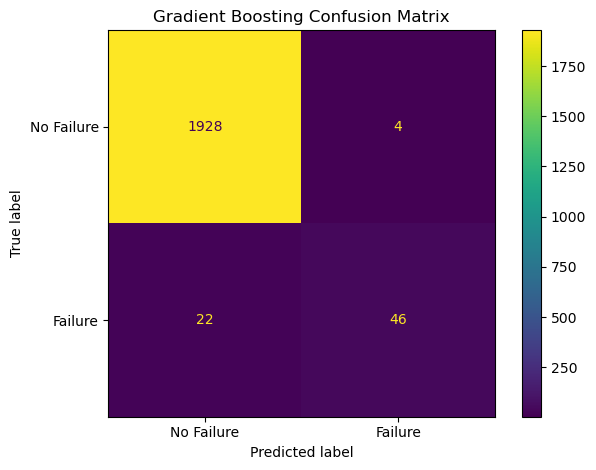

In [76]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=gb_cm,
    display_labels=["No Failure", "Failure"]
).plot()

plt.title("Gradient Boosting Confusion Matrix")
plt.tight_layout()
plt.show()

## 21. Business & Maintenance Insights

The analysis and machine learning results provide several actionable insights for predictive maintenance.

### Key Insights

1. **Torque is the strongest predictive signal**
   - Gradient Boosting identified torque as the most important feature, with approximately 45% of total feature importance.
   - Monitoring abnormal torque conditions should therefore be a priority.

2. **High tool wear is associated with increased failure risk**
   - Machines with tool wear above 200 minutes showed a substantially higher observed failure rate during EDA.
   - Maintenance inspections should become more frequent as tool wear approaches this range.

3. **Rotational speed is an important operating variable**
   - Rotational speed was among the three most important model features.
   - Monitoring unusual speed conditions together with torque may help identify machines at higher risk.

4. **Temperature contributes to failure prediction**
   - Air temperature and process temperature provided additional predictive information.
   - Temperature monitoring can complement torque, speed, and tool-wear monitoring.

5. **Gradient Boosting provides the best overall model balance**
   - The model achieved 92% failure precision, 68% failure recall, 78% failure F1-score, and 0.965 ROC-AUC.
   - It detected 46 of the 68 failures in the test set while generating only 4 false alarms.

### Maintenance Recommendations

- Prioritize monitoring of **torque and rotational speed**.
- Establish preventive inspection thresholds around **high tool-wear levels**.
- Combine multiple machine signals rather than relying on a single measurement.
- Use the predictive model as an **early-warning system** to prioritize maintenance inspections.
- Review model predictions alongside operational knowledge before taking maintenance action.

## 22. Conclusion

This project developed an end-to-end predictive maintenance workflow for identifying machine failure risk.

The analysis began with exploratory data analysis to understand machine operating conditions and failure patterns. Three classification models were then evaluated:

- Logistic Regression
- Random Forest
- Gradient Boosting

Gradient Boosting achieved the strongest overall performance, with a **ROC-AUC of 0.965**, **92% failure precision**, **68% failure recall**, and a **78% failure F1-score**.

Feature importance analysis showed that **Torque [Nm]**, **Tool wear [min]**, and **Rotational speed [rpm]** were the most influential variables in the final model.

The results demonstrate how machine operating data can be used to identify machines at elevated failure risk and support proactive maintenance decisions.

This model should be viewed as a decision-support and early-warning system rather than a replacement for engineering judgment or scheduled maintenance procedures.